# Apply Halofit Selection Criteria to CosmoGRID Simulations

This notebook applies the Halofit model validity criteria to select a subset of CosmoGRID simulations.

## Selection Criteria

The Halofit model is valid for the following parameter ranges:
- $\Omega_m$: [0.21, 0.4]
- $\omega_b$: [0.02, 0.024] (physical baryon density)
- $n_s$: [0.85, 1.05]
- $\sigma_8$: [0.61, 0.9]
- $w_0$: [-1.05, -0.95]

## Parameter Conversions

Our simulations use: [$\Omega_m$, $\sigma_8$, $w_0$, $H_0$, $n_s$, $\Omega_b$]

We need to compute:
- $\omega_b = \Omega_b \cdot h^2$, where $h = H_0/100$

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
from tqdm import tqdm

## Load CosmoGRID Parameters

In [26]:
# Load the full parameter array
params_file = '/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params.npy'
params = np.load(params_file, allow_pickle=True)

print(f"Total parameter sets: {params.shape[0]}")
print(f"Number of parameters: {params.shape[1]}")
print(f"\nParameter order: Omega_m, sigma_8, w_0, H_0, n_s, Omega_b")

Total parameter sets: 16965
Number of parameters: 6

Parameter order: Omega_m, sigma_8, w_0, H_0, n_s, Omega_b


## Extract Individual Parameters

In [27]:
# Extract individual parameters (column indices)
Omega_m = params[:, 0]
sigma_8 = params[:, 1]
w_0 = params[:, 2]
H_0 = params[:, 3]
n_s = params[:, 4]
Omega_b = params[:, 5]

print("Parameter ranges in full grid:")
print(f"Omega_m: [{Omega_m.min():.4f}, {Omega_m.max():.4f}]")
print(f"sigma_8: [{sigma_8.min():.4f}, {sigma_8.max():.4f}]")
print(f"w_0:     [{w_0.min():.4f}, {w_0.max():.4f}]")
print(f"H_0:     [{H_0.min():.4f}, {H_0.max():.4f}]")
print(f"n_s:     [{n_s.min():.4f}, {n_s.max():.4f}]")
print(f"Omega_b: [{Omega_b.min():.4f}, {Omega_b.max():.4f}]")

Parameter ranges in full grid:
Omega_m: [0.1004, 0.4999]
sigma_8: [0.4002, 1.3973]
w_0:     [-1.9349, -0.3338]
H_0:     [64.0044, 81.9868]
n_s:     [0.8701, 1.0699]
Omega_b: [0.0300, 0.0600]


## Compute Derived Parameters

### 1. Physical baryon density: $\omega_b = \Omega_b \cdot h^2$

In [28]:
# Compute h = H_0 / 100
h = H_0 / 100.0

# Compute omega_b = Omega_b * h^2
omega_b = Omega_b * h**2

print(f"omega_b range: [{omega_b.min():.6f}, {omega_b.max():.6f}]")
print(f"Required range: [0.020000, 0.024000]")

omega_b range: [0.012598, 0.039882]
Required range: [0.020000, 0.024000]


## Apply Halofit Selection Criteria

In [40]:
# Define selection criteria
criteria = {
    'Omega_m': (0.21, 0.4),
    'omega_b': (0.02, 0.024),
    'n_s': (0.85, 1.05),
    'sigma_8': (0.61, 0.9),
    'w_0': (-1.15, -0.85)
}

# Apply each criterion
mask_Omega_m = (Omega_m >= criteria['Omega_m'][0]) & (Omega_m <= criteria['Omega_m'][1])
mask_omega_b = (omega_b >= criteria['omega_b'][0]) & (omega_b <= criteria['omega_b'][1])
mask_n_s = (n_s >= criteria['n_s'][0]) & (n_s <= criteria['n_s'][1])
mask_sigma_8 = (sigma_8 >= criteria['sigma_8'][0]) & (sigma_8 <= criteria['sigma_8'][1])
mask_w_0 = (w_0 >= criteria['w_0'][0]) & (w_0 <= criteria['w_0'][1])

# Combine all criteria
final_mask = mask_Omega_m & mask_omega_b & mask_n_s & mask_sigma_8 & mask_w_0

# Report results for each criterion
print("Selection results:")
print("="*60)
print(f"Omega_m in [{criteria['Omega_m'][0]}, {criteria['Omega_m'][1]}]: {mask_Omega_m.sum():6d} / {len(params)} ({100*mask_Omega_m.sum()/len(params):.1f}%)")
print(f"omega_b in [{criteria['omega_b'][0]}, {criteria['omega_b'][1]}]: {mask_omega_b.sum():6d} / {len(params)} ({100*mask_omega_b.sum()/len(params):.1f}%)")
print(f"n_s     in [{criteria['n_s'][0]}, {criteria['n_s'][1]}]: {mask_n_s.sum():6d} / {len(params)} ({100*mask_n_s.sum()/len(params):.1f}%)")
print(f"sigma_8 in [{criteria['sigma_8'][0]}, {criteria['sigma_8'][1]}]: {mask_sigma_8.sum():6d} / {len(params)} ({100*mask_sigma_8.sum()/len(params):.1f}%)")
print(f"w_0     in [{criteria['w_0'][0]}, {criteria['w_0'][1]}]: {mask_w_0.sum():6d} / {len(params)} ({100*mask_w_0.sum()/len(params):.1f}%)")
print("="*60)
print(f"\nFinal selection (all criteria): {final_mask.sum()} / {len(params)} ({100*final_mask.sum()/len(params):.1f}%)")

Selection results:
Omega_m in [0.21, 0.4]:  10602 / 16965 (62.5%)
omega_b in [0.02, 0.024]:   6934 / 16965 (40.9%)
n_s     in [0.85, 1.05]:  16125 / 16965 (95.0%)
sigma_8 in [0.61, 0.9]:   7200 / 16965 (42.4%)
w_0     in [-1.15, -0.85]:   7431 / 16965 (43.8%)

Final selection (all criteria): 1299 / 16965 (7.7%)


## Extract Selected Parameters

In [41]:
# Extract selected parameters
selected_params = params[final_mask]
selected_indices = np.where(final_mask)[0]

print(f"Number of selected simulations: {len(selected_params)}")
print(f"\nSelected parameter ranges:")
print(f"Omega_m: [{selected_params[:, 0].min():.4f}, {selected_params[:, 0].max():.4f}]")
print(f"sigma_8: [{selected_params[:, 1].min():.4f}, {selected_params[:, 1].max():.4f}]")
print(f"w_0:     [{selected_params[:, 2].min():.4f}, {selected_params[:, 2].max():.4f}]")
print(f"H_0:     [{selected_params[:, 3].min():.4f}, {selected_params[:, 3].max():.4f}]")
print(f"n_s:     [{selected_params[:, 4].min():.4f}, {selected_params[:, 4].max():.4f}]")
print(f"Omega_b: [{selected_params[:, 5].min():.4f}, {selected_params[:, 5].max():.4f}]")

# Also show derived parameters
selected_omega_b = omega_b[final_mask]

print(f"\nDerived parameters:")
print(f"omega_b: [{selected_omega_b.min():.6f}, {selected_omega_b.max():.6f}]")

Number of selected simulations: 1299

Selected parameter ranges:
Omega_m: [0.2112, 0.3999]
sigma_8: [0.6111, 0.8985]
w_0:     [-1.1486, -0.8511]
H_0:     [64.5449, 81.4375]
n_s:     [0.8734, 1.0454]
Omega_b: [0.0322, 0.0547]

Derived parameters:
omega_b: [0.020005, 0.023984]


## Visualize Parameter Distributions

### Before and After Selection

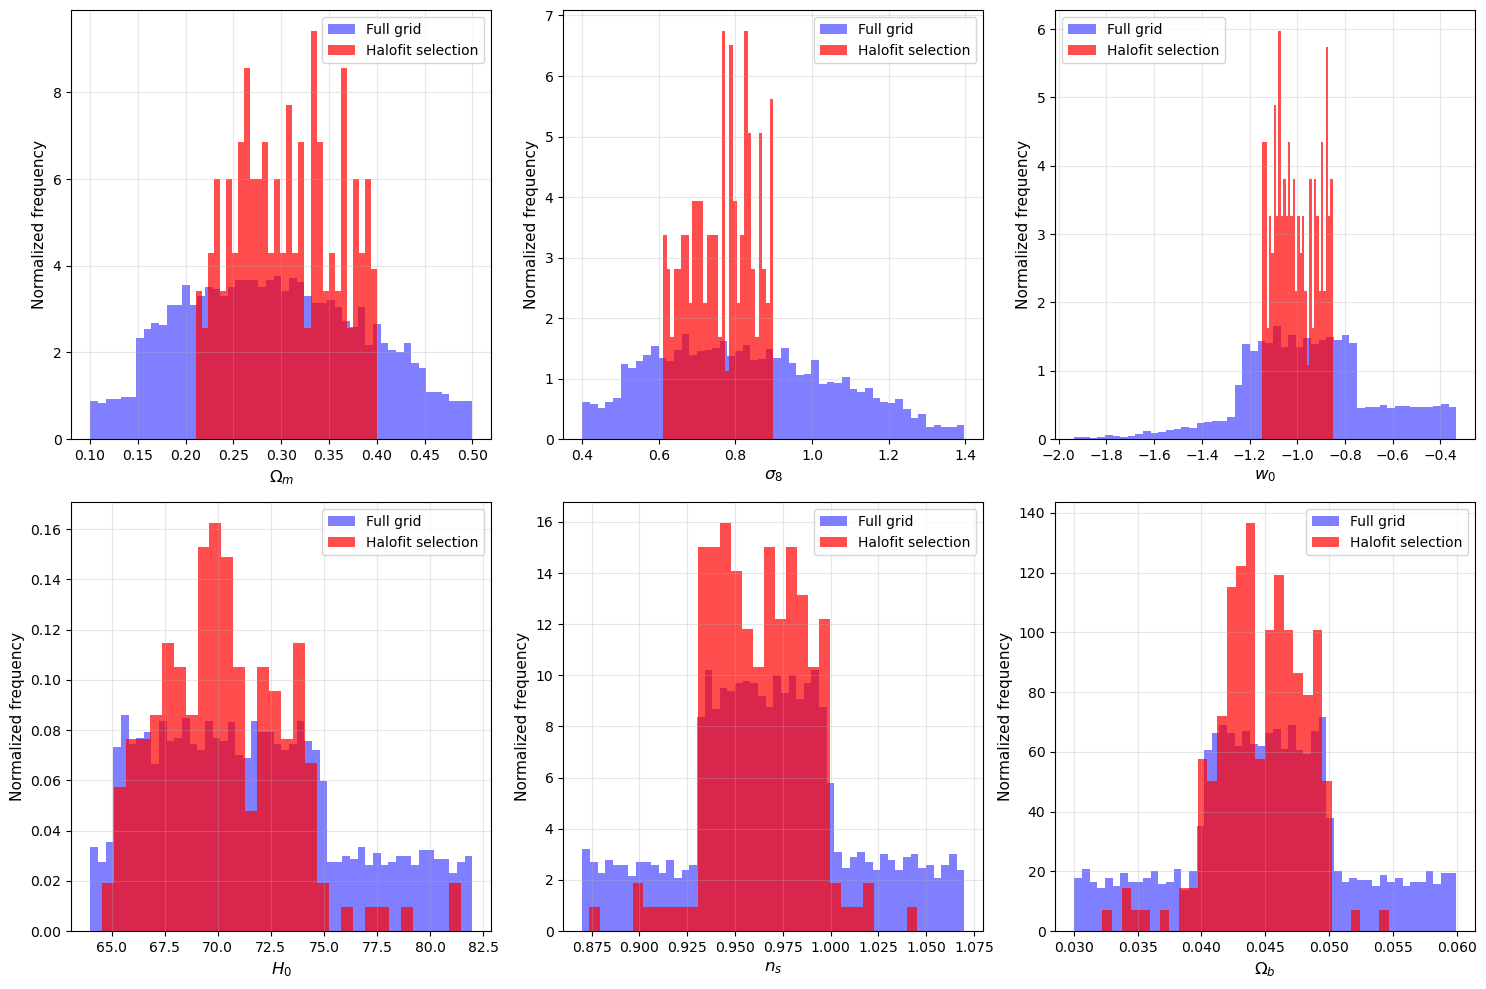

Figure saved to ../plots/halofit_selection_comparison.png


In [42]:
# Create comprehensive visualization
param_names = ['$\Omega_m$', '$\sigma_8$', '$w_0$', '$H_0$', '$n_s$', '$\Omega_b$']
n_params = 6

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(n_params):
    ax = axes[i]
    
    # Plot full distribution
    ax.hist(params[:, i], bins=50, alpha=0.5, label='Full grid', color='blue', density=True)
    
    # Plot selected distribution
    ax.hist(selected_params[:, i], bins=30, alpha=0.7, label='Halofit selection', 
            color='red', density=True)
    
    ax.set_xlabel(param_names[i], fontsize=12)
    ax.set_ylabel('Normalized frequency', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/halofit_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to ../plots/halofit_selection_comparison.png")

### Derived Parameters Distribution

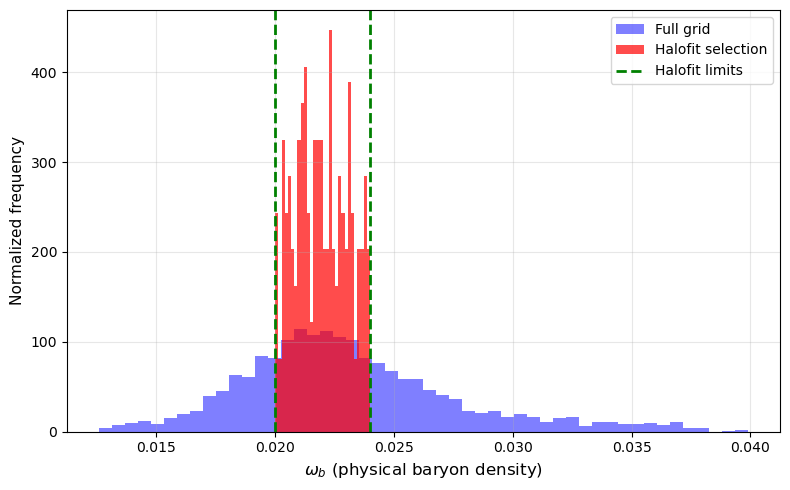

Figure saved to ../plots/halofit_selection_omega_b.png


In [43]:
# Plot omega_b (derived parameter)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# omega_b
ax.hist(omega_b, bins=50, alpha=0.5, label='Full grid', color='blue', density=True)
ax.hist(selected_omega_b, bins=30, alpha=0.7, label='Halofit selection', 
        color='red', density=True)
ax.axvline(0.02, color='green', linestyle='--', linewidth=2, label='Halofit limits')
ax.axvline(0.024, color='green', linestyle='--', linewidth=2)
ax.set_xlabel('$\omega_b$ (physical baryon density)', fontsize=12)
ax.set_ylabel('Normalized frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/halofit_selection_omega_b.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to ../plots/halofit_selection_omega_b.png")

## 2D Parameter Correlations

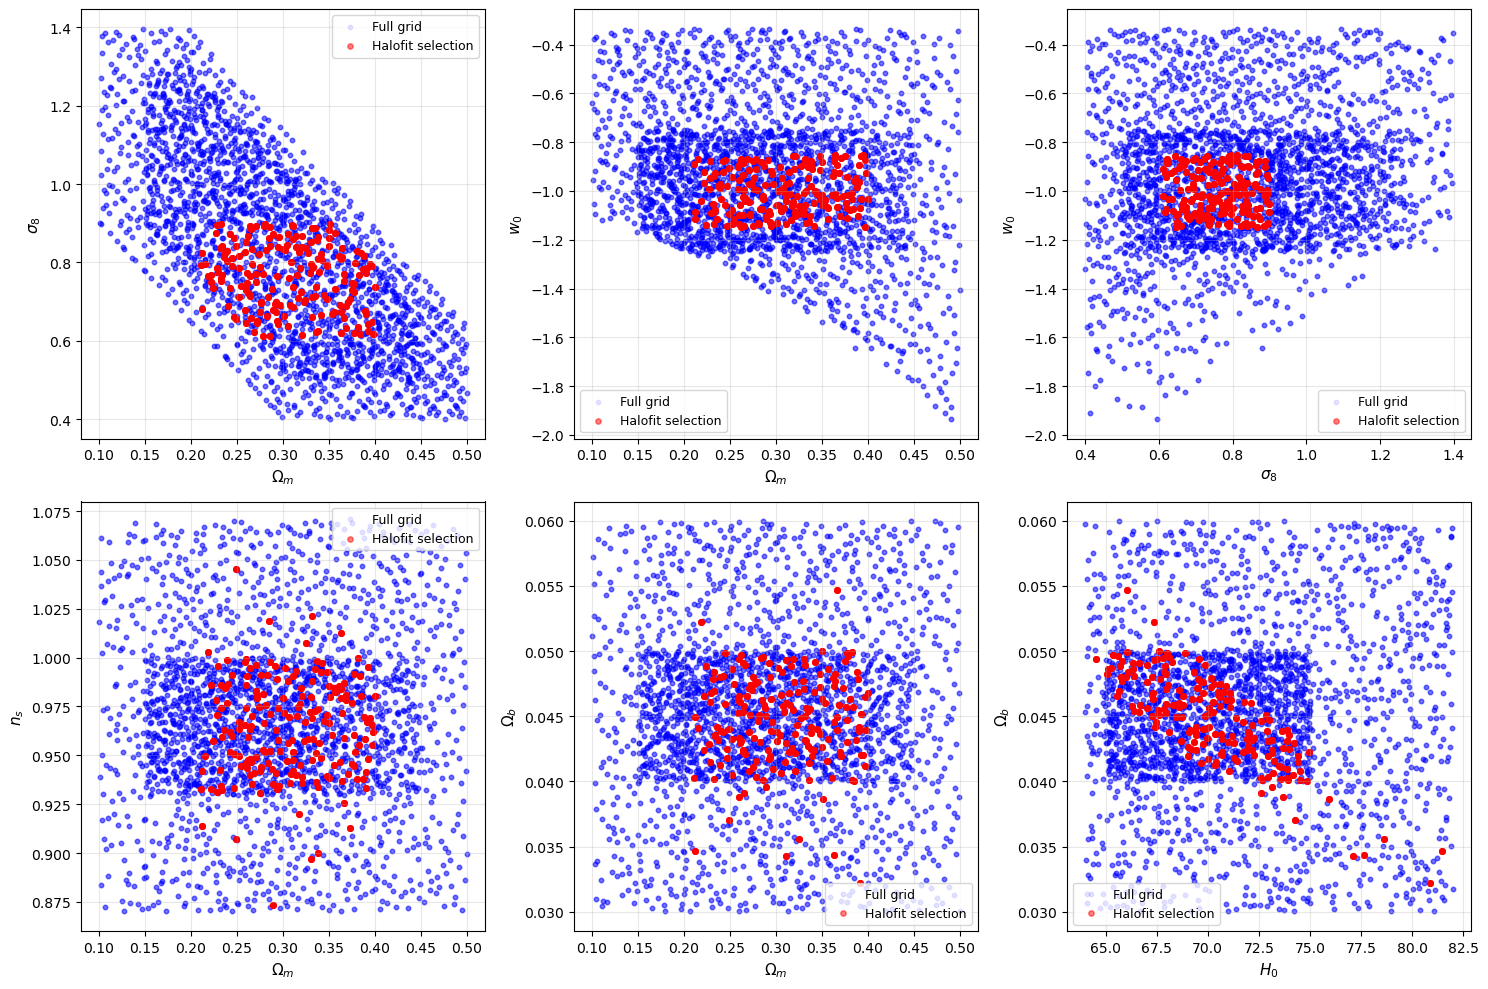

Figure saved to ../plots/halofit_selection_2d_correlations.png


In [44]:
# Create 2D scatter plots for key parameter pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

param_pairs = [
    (0, 1, '$\Omega_m$', '$\sigma_8$'),
    (0, 2, '$\Omega_m$', '$w_0$'),
    (1, 2, '$\sigma_8$', '$w_0$'),
    (0, 4, '$\Omega_m$', '$n_s$'),
    (0, 5, '$\Omega_m$', '$\Omega_b$'),
    (3, 5, '$H_0$', '$\Omega_b$'),
]

for idx, (i, j, name_i, name_j) in enumerate(param_pairs):
    ax = axes[idx]
    
    # Plot full grid
    ax.scatter(params[:, i], params[:, j], alpha=0.1, s=10, color='blue', 
               label='Full grid')
    
    # Plot selected points
    ax.scatter(selected_params[:, i], selected_params[:, j], alpha=0.5, s=15, 
               color='red', label='Halofit selection')
    
    ax.set_xlabel(name_i, fontsize=11)
    ax.set_ylabel(name_j, fontsize=11)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/halofit_selection_2d_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to ../plots/halofit_selection_2d_correlations.png")

## Save Selected Parameters and Indices

In [45]:
# Save selected parameters
output_dir = Path('../data')
output_dir.mkdir(exist_ok=True)

# Save the selected parameters
np.save(output_dir / 'selected_params_halofit.npy', selected_params)

# Save the indices
np.save(output_dir / 'selected_indices_halofit.npy', selected_indices)

# Save the mask
np.save(output_dir / 'selection_mask_halofit.npy', final_mask)

# Create a metadata file
metadata = {
    'total_simulations': len(params),
    'selected_simulations': len(selected_params),
    'selection_fraction': len(selected_params) / len(params),
    'criteria': criteria,
    'parameter_names': ['Omega_m', 'sigma_8', 'w_0', 'H_0', 'n_s', 'Omega_b'],
}

import json
with open(output_dir / 'halofit_selection_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved selected parameters to {output_dir}/selected_params_halofit.npy")
print(f"Saved selection indices to {output_dir}/selected_indices_halofit.npy")
print(f"Saved selection mask to {output_dir}/selection_mask_halofit.npy")
print(f"Saved metadata to {output_dir}/halofit_selection_metadata.json")

Saved selected parameters to ../data/selected_params_halofit.npy
Saved selection indices to ../data/selected_indices_halofit.npy
Saved selection mask to ../data/selection_mask_halofit.npy
Saved metadata to ../data/halofit_selection_metadata.json


## Map Simulations to File Paths

Let's identify which simulation files correspond to our selected parameters.

In [46]:
# CosmoGRID structure: cosmo_XXXXXX/perm_YYYY/projected_probes_maps_nobaryons512.h5
# The cosmology directory numbers are NOT sequential - we need to use a mapping file

base_dir = Path('/home/tersenov/CosmoGridV1/stage3_forecast/grid')

# Load the mapping from params row index to actual cosmology numbers
with open(base_dir / 'actual.txt', 'r') as f:
    actual_cosmo_nums = [int(line.strip()) for line in f if line.strip()]

print(f"Loaded mapping for {len(actual_cosmo_nums)} cosmologies")

# Map indices to file paths using the correct cosmology numbers
# index i in params array -> cosmology actual_cosmo_nums[i // 7], permutation i % 7

selected_files = []

for idx in selected_indices:
    cosmo_idx = idx // 7  # Which cosmology (0, 1, 2, ...)
    perm_num = idx % 7    # Which permutation (0-6)
    
    # Get the actual cosmology number from the mapping
    actual_cosmo_num = actual_cosmo_nums[cosmo_idx]
    
    cosmo_dir = f"cosmo_{actual_cosmo_num:06d}"
    perm_dir = f"perm_{perm_num:04d}"
    
    # Note: Only baryonified512.h5 files exist in the data directories
    file_path = base_dir / cosmo_dir / perm_dir / "projected_probes_maps_baryonified512.h5"
    
    if file_path.exists():
        selected_files.append({
            'index': idx,
            'cosmo_idx': cosmo_idx,
            'actual_cosmo_num': actual_cosmo_num,
            'cosmo_num': cosmo_num,
            'perm_num': perm_num,
            'path': str(file_path),
            'params': selected_params[np.where(selected_indices == idx)[0][0]]
        })

print(f"Found {len(selected_files)} simulation files")
print(f"\nFirst 5 selected simulations:")
for i, file_info in enumerate(selected_files[:5]):
    print(f"  {i+1}. cosmo_{file_info['cosmo_num']:04d}/perm_{file_info['perm_num']:04d}")
    print(f"     Params: Omega_m={file_info['params'][0]:.4f}, sigma_8={file_info['params'][1]:.4f}, w_0={file_info['params'][2]:.4f}")

Found 0 simulation files

First 5 selected simulations:


## Save File List

In [47]:
# Save the file list
import pickle

with open(output_dir / 'selected_files_halofit.pkl', 'wb') as f:
    pickle.dump(selected_files, f)

# Also save as a simple text file for easy inspection
with open(output_dir / 'selected_files_halofit.txt', 'w') as f:
    f.write(f"# Selected CosmoGRID simulations passing Halofit criteria\n")
    f.write(f"# Total: {len(selected_files)} simulations\n")
    f.write(f"# Format: cosmo_num perm_num Omega_m sigma_8 w_0 H_0 n_s Omega_b\n")
    f.write("#" + "="*80 + "\n")
    
    for file_info in selected_files:
        p = file_info['params']
        f.write(f"{file_info['cosmo_num']:04d} {file_info['perm_num']:04d} ")
        f.write(f"{p[0]:.6f} {p[1]:.6f} {p[2]:.6f} {p[3]:.6f} {p[4]:.6f} {p[5]:.6f}\n")

print(f"Saved file list to {output_dir}/selected_files_halofit.pkl")
print(f"Saved file list to {output_dir}/selected_files_halofit.txt")

Saved file list to ../data/selected_files_halofit.pkl
Saved file list to ../data/selected_files_halofit.txt


## Summary Statistics

In [48]:
print("="*80)
print("SUMMARY")
print("="*80)
print(f"\nTotal CosmoGRID simulations: {len(params):,}")
print(f"Simulations passing Halofit criteria: {len(selected_params):,}")
print(f"Selection efficiency: {100*len(selected_params)/len(params):.2f}%")

print(f"\nIndividual criterion efficiencies:")
print(f"  Omega_m: {100*mask_Omega_m.sum()/len(params):.1f}%")
print(f"  omega_b: {100*mask_omega_b.sum()/len(params):.1f}%")
print(f"  n_s:     {100*mask_n_s.sum()/len(params):.1f}%")
print(f"  sigma_8: {100*mask_sigma_8.sum()/len(params):.1f}%")
print(f"  w_0:     {100*mask_w_0.sum()/len(params):.1f}%")

print(f"\nNumber of unique cosmologies: {len(np.unique(np.array([f['cosmo_num'] for f in selected_files])))}")
print(f"Permutations per cosmology: variable (up to 7)")

print("\n" + "="*80)

SUMMARY

Total CosmoGRID simulations: 16,965
Simulations passing Halofit criteria: 1,299
Selection efficiency: 7.66%

Individual criterion efficiencies:
  Omega_m: 62.5%
  omega_b: 40.9%
  n_s:     95.0%
  sigma_8: 42.4%
  w_0:     43.8%

Number of unique cosmologies: 0
Permutations per cosmology: variable (up to 7)



## Optional: Create Filtered Parameter File

You can create a new parameter file containing only the selected simulations for use in downstream analysis.

In [49]:
# This would be useful if you want to train models only on Halofit-valid simulations
filtered_params_path = output_dir / 'cosmo_params_halofit.npy'
np.save(filtered_params_path, selected_params)

print(f"Saved filtered parameter file to {filtered_params_path}")
print(f"You can use this file in place of the full cosmo_params.npy for Halofit-restricted analyses.")

Saved filtered parameter file to ../data/cosmo_params_halofit.npy
You can use this file in place of the full cosmo_params.npy for Halofit-restricted analyses.


## Create Unique Parameter Set (No Duplicates)

Since multiple permutations share the same cosmology, let's also save a version with only unique parameter sets.

In [50]:
# Find unique parameter sets
unique_params, unique_indices = np.unique(selected_params, axis=0, return_index=True)

print(f"Selected simulations: {len(selected_params)}")
print(f"Unique cosmologies: {len(unique_params)}")
print(f"Average realizations per cosmology: {len(selected_params) / len(unique_params):.2f}")

# Save unique parameters
unique_params_path = output_dir / 'selected_params_halofit_unique.npy'
np.save(unique_params_path, unique_params)

print(f"\nSaved unique parameter sets to {unique_params_path}")
print(f"File size reduction: {len(selected_params)} -> {len(unique_params)} ({100*len(unique_params)/len(selected_params):.1f}%)")

# Show some statistics
print(f"\nUnique parameter ranges:")
print(f"Omega_m: [{unique_params[:, 0].min():.4f}, {unique_params[:, 0].max():.4f}]")
print(f"sigma_8: [{unique_params[:, 1].min():.4f}, {unique_params[:, 1].max():.4f}]")
print(f"w_0:     [{unique_params[:, 2].min():.4f}, {unique_params[:, 2].max():.4f}]")
print(f"H_0:     [{unique_params[:, 3].min():.4f}, {unique_params[:, 3].max():.4f}]")
print(f"n_s:     [{unique_params[:, 4].min():.4f}, {unique_params[:, 4].max():.4f}]")
print(f"Omega_b: [{unique_params[:, 5].min():.4f}, {unique_params[:, 5].max():.4f}]")

Selected simulations: 1299
Unique cosmologies: 186
Average realizations per cosmology: 6.98

Saved unique parameter sets to ../data/selected_params_halofit_unique.npy
File size reduction: 1299 -> 186 (14.3%)

Unique parameter ranges:
Omega_m: [0.2112, 0.3999]
sigma_8: [0.6111, 0.8985]
w_0:     [-1.1486, -0.8511]
H_0:     [64.5449, 81.4375]
n_s:     [0.8734, 1.0454]
Omega_b: [0.0322, 0.0547]
